# Notebook 04 — Dynamic Pricing Model
**Input:** ETA predictions from `models/eta_rf.joblib`  
**Output:** `models/pricing_config.joblib`

Implements demand/supply-aware surge pricing on top of predicted ETA.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Ready')


Ready


---
## 1. Pricing Logic
Base price is distance-based. Surge multiplier is derived from:
- Rush hour flag (×1.3)
- Rain flag (×1.15)
- Snow flag (×1.25)
- Weekend evening (×1.1)
- Min/max caps applied (1.0 – 2.5×)


In [2]:
BASE_RATE_PER_KM = 2.50   # USD per km
BASE_MINIMUM     = 5.00   # minimum fare USD

SURGE_CONFIG = {
    'rush_hour':       1.30,
    'rain':            1.15,
    'snow':            1.25,
    'weekend_evening': 1.10,
    'surge_min':       1.00,
    'surge_max':       2.50,
}

def compute_surge(hour: int, is_weekend: int, is_rainy: int, is_snowy: int) -> float:
    multiplier = 1.0
    if hour in {8,9,17,18,19}:
        multiplier *= SURGE_CONFIG['rush_hour']
    if is_rainy:
        multiplier *= SURGE_CONFIG['rain']
    if is_snowy:
        multiplier *= SURGE_CONFIG['snow']
    if is_weekend and hour >= 20:
        multiplier *= SURGE_CONFIG['weekend_evening']
    return float(np.clip(multiplier, SURGE_CONFIG['surge_min'], SURGE_CONFIG['surge_max']))

def compute_price(trip_distance: float, surge: float) -> dict:
    base  = max(BASE_MINIMUM, trip_distance * BASE_RATE_PER_KM)
    final = round(base * surge, 2)
    return {'base_price': round(base,2), 'surge_multiplier': round(surge,3), 'final_price': final}

# Quick test
print('Rush rain test:', compute_price(3.5, compute_surge(18, 0, 1, 0)))
print('Normal test:   ', compute_price(2.0, compute_surge(14, 0, 0, 0)))


Rush rain test: {'base_price': 8.75, 'surge_multiplier': 1.495, 'final_price': 13.08}
Normal test:    {'base_price': 5.0, 'surge_multiplier': 1.0, 'final_price': 5.0}


---
## 2. Validate Against Delivery Orders Dataset


In [7]:
meta     = joblib.load('models/feature_pipeline.joblib')
FEATURES = meta['features']

test = pd.read_csv('data/processed/test_features.csv')
test['order_time'] = pd.to_datetime(test['order_time'], format='mixed')

rf_bundle = joblib.load('models/eta_rf.joblib')
rf        = rf_bundle['model']

test['eta_pred']     = rf.predict(test[FEATURES].values)
test['hour']         = test['order_time'].dt.hour
test['is_weekend']   = (test['order_time'].dt.dayofweek >= 5).astype(int)
test['is_snowy']     = 0   # no snow column in features — use prcp proxy

test['surge']        = test.apply(
    lambda r: compute_surge(int(r['hour']), int(r['is_weekend']),
                             int(r['is_rainy']), int(r['is_snowy'])), axis=1)
pricing              = test.apply(
    lambda r: compute_price(r['trip_distance'], r['surge']), axis=1, result_type='expand')
test = pd.concat([test, pricing], axis=1)

print(test[['eta_pred','base_price','surge_multiplier','final_price']].describe().round(2).to_string())


         eta_pred  base_price  surge_multiplier  final_price
count  1857244.00  1857244.00        1857244.00   1857244.00
mean        23.17        9.74              1.11        10.79
std         12.47       10.29              0.14        11.47
min          7.50        5.00              1.00         5.00
25%         14.97        5.00              1.00         5.00
50%         19.75        5.00              1.00         6.50
75%         27.20        8.73              1.30         9.72
max        148.09      125.00              1.50       178.43


---
## 3. Surge Distribution


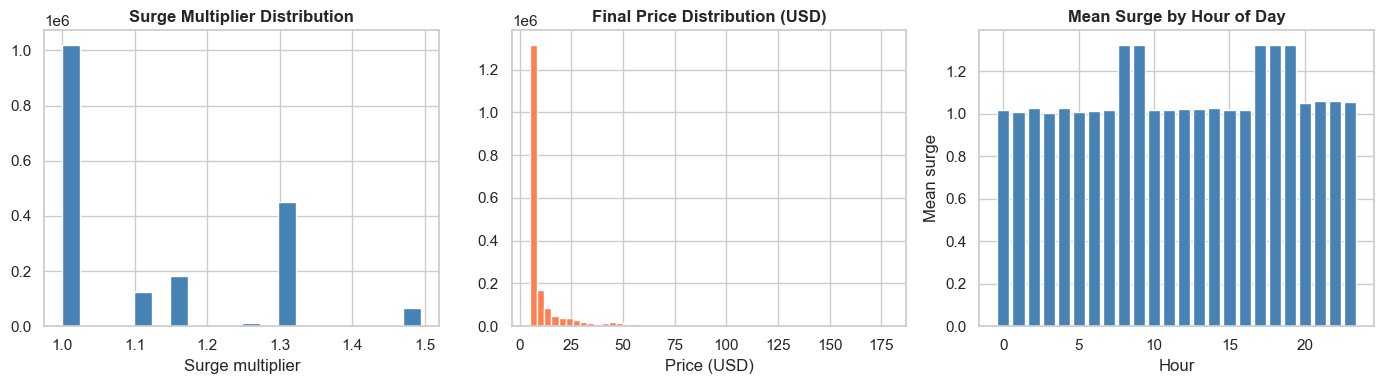

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(test['surge'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Surge Multiplier Distribution', fontweight='bold')
axes[0].set_xlabel('Surge multiplier')

axes[1].hist(test['final_price'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Final Price Distribution (USD)', fontweight='bold')
axes[1].set_xlabel('Price (USD)')

surge_hour = test.groupby('hour')['surge'].mean()
axes[2].bar(surge_hour.index, surge_hour.values, color='steelblue', edgecolor='white')
axes[2].set_title('Mean Surge by Hour of Day', fontweight='bold')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Mean surge')

plt.tight_layout()
plt.savefig('../data/processed/eda_pricing.png', bbox_inches='tight')
plt.show()


In [9]:
import os; os.makedirs('models', exist_ok=True)
joblib.dump({'surge_config': SURGE_CONFIG,
             'base_rate': BASE_RATE_PER_KM,
             'base_minimum': BASE_MINIMUM},
            'models/pricing_config.joblib')
print('Saved → models/pricing_config.joblib')


Saved → models/pricing_config.joblib
